# Лабораторная работа №3

### 1. Оценка параметра λ методом Метрополиса-Гастингса

Оценка λ (MH): 0.498859


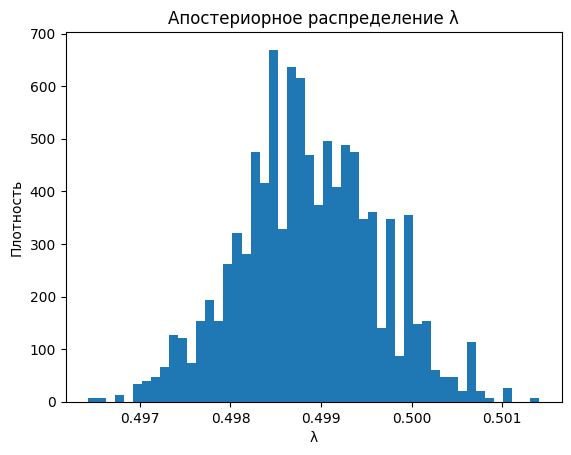

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Параметры задачи
V = 150.0
Gs = 5.0
C0 = 5.0
Coa = 400.0
sigma = 5.0
sigma2 = sigma**2

# Загрузка данных
y = np.loadtxt('data.txt')
n = len(y)
t = np.arange(n, dtype=float)  # t = 0, 1, ..., n-1 секунд

def C_pred(lam, t):
    """Аналитическое решение ОДУ"""
    if lam <= 0:
        return np.full_like(t, np.inf)
    C_inf = Coa + Gs / lam
    return C_inf + (C0 - C_inf) * np.exp(-lam * t / V)

def log_likelihood(lam):
    """Логарифм правдоподобия (Gaussian noise)"""
    C = C_pred(lam, t)
    residuals = y - C
    return -0.5 * n * np.log(2 * np.pi * sigma2) - 0.5 / sigma2 * np.sum(residuals**2)

# Метрополис-Гастингс
def metropolis_hastings(n_iter=20000, burn_in=5000, thin=10, lam_init=0.05, proposal_sd_log=0.05):
    log_lam = np.log(lam_init)
    samples = []
    current_loglik = log_likelihood(np.exp(log_lam))
    
    for i in range(n_iter):
        # Предлагаем новое значение λ
        log_lam_prop = log_lam + np.random.normal(0, proposal_sd_log)
        lam_prop = np.exp(log_lam_prop)
        prop_loglik = log_likelihood(lam_prop)
        
        # Решаем, принимаем ли предложение
        log_alpha = prop_loglik - current_loglik
        if np.log(np.random.rand()) < log_alpha:
            log_lam = log_lam_prop
            current_loglik = prop_loglik
        
        # Сохраняем после burn-in
        if i >= burn_in and (i - burn_in) % thin == 0:
            samples.append(np.exp(log_lam))
    
    lam_est = np.mean(samples)
    print(f"Оценка λ (MH): {lam_est:.6f}")
    return np.array(samples), lam_est

# Запуск
samples, lam_est = metropolis_hastings()

# Гистограмма апостериорного распределения λ
plt.hist(samples, bins=50, density=True)
plt.xlabel('λ')
plt.ylabel('Плотность')
plt.title('Апостериорное распределение λ')
plt.show()

### 2. Collapsed Gibbs sampling для LDA

In [21]:
import numpy as np
from tqdm import tqdm
from numba import njit

# функция одной итерации gibbs sampling с ускорением numba
@njit(fastmath=True)
def gibbs_sweep_numba(n_dk, n_kw, n_k, doc_words, z, T, W, alpha, beta):
    """Одна итерация Gibbs"""
    D = len(doc_words)
    for d in range(D):
        dw = doc_words[d]
        zd = z[d]
        for pos in range(len(dw)):
            w = dw[pos]
            k_old = zd[pos]

            # убираем старый топик
            n_dk[d, k_old] -= 1
            n_kw[k_old, w] -= 1
            n_k[k_old] -= 1

            # векторизованный расчёт вероятностей
            p = (n_dk[d] + alpha) * (n_kw[:, w] + beta) / (n_k + W * beta)
            p_sum = p.sum()
            if p_sum <= 0.0:
                p = np.ones(T) / T
            else:
                p /= p_sum

            # семплируем новый топик
            cum = np.cumsum(p)
            k_new = np.searchsorted(cum, np.random.rand())

            # добавляем обратно
            zd[pos] = k_new
            n_dk[d, k_new] += 1
            n_kw[k_new, w] += 1
            n_k[k_new] += 1

    return n_dk, n_kw, n_k, z


# основная функция запуска lda с gibbs sampling
def run_lda_gibbs(filename, T, alpha, beta, num_iter=500, seed=42):
    print(f'Загружаем {filename}...')
    data = np.loadtxt(filename, dtype=int)
    docs = data[:, 0] - 1
    words = data[:, 1] - 1
    counts = data[:, 2]

    D = int(docs.max()) + 1
    W = int(words.max()) + 1

    # построение списка слов для каждого документа
    doc_words = [[] for _ in range(D)]
    for d, w, c in zip(docs, words, counts):
        doc_words[d].extend([w] * int(c))
    doc_words = [np.array(lst, dtype=np.int32) for lst in doc_words]

    total_tokens = sum(len(dw) for dw in doc_words)
    print(f'Корпус: D={D}, W={W}, токенов = {total_tokens:,}')

    rng = np.random.default_rng(seed)

    # Инициализация
    z = [rng.integers(0, T, size=len(doc_words[d]), dtype=np.int32) for d in range(D)]
    n_dk = np.zeros((D, T), dtype=np.int32)
    n_kw = np.zeros((T, W), dtype=np.int32)
    n_k  = np.zeros(T, dtype=np.int32)

    for d in range(D):
        for pos in range(len(doc_words[d])):
            w = doc_words[d][pos]
            k = z[d][pos]
            n_dk[d, k] += 1
            n_kw[k, w] += 1
            n_k[k] += 1

    # Главный цикл
    iterator = tqdm(range(num_iter), desc=f"Gibbs {filename}")

    for it in iterator:
        n_dk, n_kw, n_k, z = gibbs_sweep_numba(
            n_dk, n_kw, n_k, doc_words, z, T, W, alpha, beta)

    # оценка параметров theta и phi после сэмплирования
    theta = (n_dk + alpha) / (n_dk.sum(axis=1)[:, None] + T * alpha)
    phi   = (n_kw + beta) / (n_k[:, None] + W * beta)

    print(f'{filename} готов! (итераций = {num_iter})\n')
    return theta, phi


# запуск программы для тестовых файлов
print('=== test1.dat ===')
theta1, phi1 = run_lda_gibbs('test1.dat', T=3, alpha=1.0, beta=1.0, num_iter=300)

print('\n=== test2.dat ===')
theta2, phi2 = run_lda_gibbs('test2.dat', T=20, alpha=0.1, beta=0.1, num_iter=500)

# вывод результатов
print('\n=== РЕЗУЛЬТАТЫ test1.dat ===')
print('Theta:', theta1.shape, '\n', theta1.round(6))
print('Phi:', phi1.shape, '\n', phi1.round(6))

print('\n=== РЕЗУЛЬТАТЫ test2.dat (первые строки) ===')
print('Theta (первые 10 доков):', theta2[:10].round(6))
print('Phi (первые 5 тем, первые 10 слов):', phi2[:, :10].round(6))

=== test1.dat ===
Загружаем test1.dat...
Корпус: D=6, W=6, токенов = 150


Gibbs test1.dat: 100%|██████████| 300/300 [00:00<00:00, 471.70it/s]


test1.dat готов! (итераций = 300)


=== test2.dat ===
Загружаем test2.dat...
Корпус: D=2000, W=6906, токенов = 271,898


Gibbs test2.dat: 100%|██████████| 500/500 [00:31<00:00, 15.93it/s]

test2.dat готов! (итераций = 500)


=== РЕЗУЛЬТАТЫ test1.dat ===
Theta: (6, 3) 
 [[0.023256 0.604651 0.372093]
 [0.488372 0.046512 0.465116]
 [0.465116 0.511628 0.023256]
 [0.153846 0.769231 0.076923]
 [0.076923 0.076923 0.846154]
 [0.846154 0.076923 0.076923]]
Phi: (3, 6) 
 [[0.017857 0.035714 0.035714 0.017857 0.464286 0.428571]
 [0.419355 0.403226 0.048387 0.080645 0.016129 0.032258]
 [0.02     0.02     0.46     0.44     0.02     0.04    ]]

=== РЕЗУЛЬТАТЫ test2.dat (первые строки) ===
Theta (первые 10 доков): [[3.33000e-04 3.33000e-04 3.33000e-04 3.33000e-04 3.33000e-04 2.03330e-02
  1.47000e-01 2.50333e-01 3.33000e-04 3.03667e-01 3.33000e-04 3.33000e-04
  3.33000e-04 3.33000e-04 3.33000e-04 8.03330e-02 1.07000e-01 3.66700e-03
  8.36670e-02 3.33000e-04]
 [2.04100e-03 2.04100e-03 2.04100e-03 2.04100e-03 2.04100e-03 2.04100e-03
  4.28570e-02 8.38776e-01 2.04100e-03 2.04100e-03 2.04100e-03 2.04100e-03
  2.04100e-03 2.04100e-03 2.04100e-03 2.04100e-03 2.04100e-03 8.36730e-02
  2.04100e

### 3. MCMC (Gibbs sampler) для модели Поттса на клеточной структуре

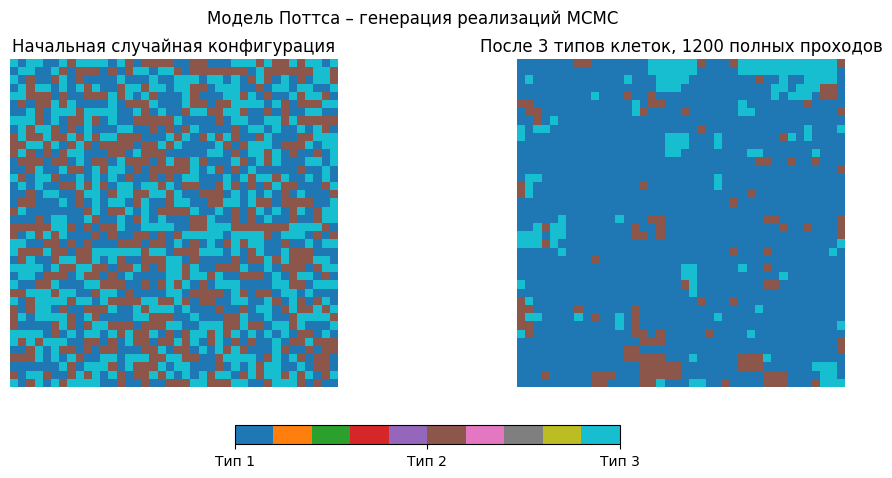

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Параметры модели

# Размер сетки (решётки) — 40x40 клеток
rows, cols = 40, 40

# Количество типов клеток
states = 3

# Матрица взаимодействий β
# beta_mat[s1, s2] — коэффициент взаимодействия между клеткой типа s1 и соседом типа s2
# Положительное значение — притяжение (выгодно быть рядом)
# Отрицательное значение — отталкивание (невыгодно быть рядом)
beta_mat = np.array([
    [1.0,  0.0,  0.0],
    [0.0,  1.0, -0.5],
    [0.0, -0.5,  1.0]
])


def potts_gibbs(rows, cols, beta_mat, num_sweeps=1200, seed=42):
    """
    Реализация Gibbs-сэмплирования для модели Поттса на двумерной решётке.
    """
    
    # Инициализация генератора случайных чисел
    rng = np.random.default_rng(seed)
    
    # Создаём начальную случайную конфигурацию
    X = rng.integers(0, states, size=(rows, cols))
    
    # Выполняем num_sweeps полных проходов по сетке
    for sweep in range(num_sweeps):
        
        for i in range(rows):
            for j in range(cols):
                
                # Определяем соседей текущей клетки
                neigh = []
                if i > 0:          neigh.append(X[i-1, j])
                if i < rows-1:     neigh.append(X[i+1, j])
                if j > 0:          neigh.append(X[i, j-1])
                if j < cols-1:     neigh.append(X[i, j+1])
                
                # Вычисляем логарифм "веса" для каждого возможного состояния s
                logp = np.zeros(states)
                for s in range(states):
                    # Суммируем взаимодействия с текущими соседями
                    logp[s] = sum(beta_mat[s, n] for n in neigh)
                
                # вычитаем максимум перед экспонентой
                max_logp = np.max(logp)
                p = np.exp(logp - max_logp)
                p /= p.sum() # нормируем
                
                # Сэмплируем новое состояние клетки согласно вычисленным вероятностям
                X[i, j] = rng.choice(states, p=p)
    
    return X


np.random.seed(42)

# Генерируем начальную случайную конфигурацию
X_init = np.random.randint(0, states, size=(rows, cols))

# Запускаем Gibbs-сэмплирование (MCMC) и получаем финальную конфигурацию
X_final = potts_gibbs(rows, cols, beta_mat)

# Визуализация
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
im0 = axs[0].imshow(X_init, cmap='tab10', vmin=0, vmax=2)
axs[0].set_title('Начальная случайная конфигурация')
axs[0].axis('off')

im1 = axs[1].imshow(X_final, cmap='tab10', vmin=0, vmax=2)
axs[1].set_title(f'После {len(beta_mat)} типов клеток, 1200 полных проходов')
axs[1].axis('off')

cbar = fig.colorbar(im1, ax=axs, orientation='horizontal', fraction=0.05, pad=0.1)
cbar.set_ticks([0, 1, 2])
cbar.set_ticklabels(['Тип 1', 'Тип 2', 'Тип 3'])
plt.suptitle('Модель Поттса – генерация реализаций MCMC')
plt.show()